# Knot diagrams from signed Gauss codes

This notebook implements the pipeline from my post
[Generating SVG for the Prime Knots](https://prideout.net/blog/svg_knots/):

![Conceptual pipeline](assets/pipeline_steps.svg)

Equivalently, in terms of the data products we build along the way:

![Data products](assets/pipeline_artifacts.svg)

The central guarantee is preservation of the input embedding. Given a signed Gauss code that
represents a valid classical planar diagram, orientation recovery and circle packing produce
a planar drawing of that same shadow graph, so the layout introduces no accidental
intersections. If the input code is already a minimal-crossing diagram, the output preserves
that crossing count.


# Stage 0: Setup and examples

The first cell imports only standard-library modules, defines a tiny SVG display helper, and
stores the bare signed Gauss examples used by the pipeline. These lists have over/under
signs but no local `a/c` orientation. The orientation letters are derived later, not baked
into the input data.

An **enhanced Gauss code** is the signed Gauss word after that orientation has been recovered.
Each visit is written as a crossing label plus a two-letter tag: `o` or `u` says whether the
strand is over or under at that visit, while `a` or `c` records the local orientation class at
the crossing. For example, `3 oa` means "crossing 3, over strand, orientation class `a`."


In [1]:
import math
import re
from html import escape

try:
    from IPython.display import SVG, display
except Exception:
    SVG = None
    display = None


def show_svg(svg):
    if SVG is None or display is None:
        print(svg)
    else:
        display(SVG(svg))


SIGNED_GAUSS_EXAMPLES = {
    "3_1": [1, -2, 3, -1, 2, -3],
    "4_1": [-1, 2, -3, 1, -4, 3, -2, 4],
    "5_1": [-1, 2, -3, 4, -5, 1, -2, 3, -4, 5],
    "5_2": [1, -2, 3, -1, 4, -5, 2, -3, 5, -4],
    "6_1": [1, -2, 3, -4, 2, -1, 5, -6, 4, -3, 6, -5],
    "6_2": [1, -2, 3, -4, 5, -6, 2, -1, 6, -3, 4, -5],
    "6_3": [-1, 2, -3, 1, -4, 5, -2, 3, -6, 4, -5, 6],
    "7_4": [-1, 2, -3, 4, -5, 6, -7, 3, -2, 1, -4, 7, -6, 5],
    "8_11": [1, -2, 3, -4, 5, -6, 7, -8, 2, -1, 8, -3, 6, -5, 4, -7],
}


# Stage 1: Signed Gauss code to an embedded shadow graph

A signed Gauss word gives the order of visits along the knot and marks each visit as over or
under. It does not yet give the cyclic order of the four half-edges at every crossing, so it
needs an orientation-recovery step before it becomes a planar combinatorial embedding.


The Kauffman orientation recovery is important, but it is supporting machinery rather than
the main layout idea. This cell is collapsed by default; the next section opens up the same
process with a concrete trefoil example.


In [2]:
def crosses(pair_a, pair_b):
    a, b = pair_a
    c, d = pair_b
    if c < a:
        a, b, c, d = c, d, a, b
    return a < c < b < d


def bipartition_intersection_graph(pairings):
    colors = {}
    for start in range(len(pairings)):
        if start in colors:
            continue
        colors[start] = 0
        stack = [start]
        while stack:
            u = stack.pop()
            for v in range(len(pairings)):
                if u == v or not crosses(pairings[u], pairings[v]):
                    continue
                wanted = 1 - colors[u]
                if v in colors:
                    if colors[v] != wanted:
                        raise ValueError("the Gauss word is not classical-planar")
                else:
                    colors[v] = wanted
                    stack.append(v)
    return colors


def kauffman_orientation_steps(sage_signed_gauss):
    """Return the intermediate data used by recover_orientations."""
    signs_overunder = [1 if letter > 0 else -1 for letter in sage_signed_gauss]
    gauss = [abs(x) for x in sage_signed_gauss]
    n = len(gauss) // 2

    changed = list(gauss)
    reversal_steps = []
    for label in range(1, n + 1):
        before = list(changed)
        first = changed.index(label)
        start = changed[: first + 1]
        after_first = changed[first + 1 :]
        second = after_first.index(label)
        middle = list(reversed(after_first[:second]))
        changed = start + middle + after_first[second:]
        reversal_steps.append({
            "label": label,
            "before": before,
            "after": list(changed),
        })

    positions = [[] for _ in range(n)]
    for position, label in enumerate(changed):
        positions[label - 1].append(position)
    pairings = [tuple(pair) for pair in positions]
    colors = bipartition_intersection_graph(pairings)
    positive = sorted(pairings[index] for index, color in colors.items() if color == 0)
    negative = sorted(pairings[index] for index, color in colors.items() if color == 1)

    signs_local = {label: 1 for label in range(1, n + 1)}
    for left, _ in negative:
        signs_local[changed[left]] *= -1

    jump_from = {}
    for left, right in positive + negative:
        jump_from[left] = right
        jump_from[right] = left

    trace = []
    direction = 1
    position = 0
    for step in range(2 * n):
        label = changed[position]
        new_position = jump_from[position]
        sign = signs_local[label]
        if new_position < position:
            sign = -sign
        if direction == 1:
            sign *= signs_overunder[step]
        signs_local[label] = sign
        trace.append({
            "step": step,
            "position": position,
            "label": label,
            "jump_to": new_position,
            "direction_after": -direction,
            "local_sign": sign,
        })
        direction = -direction
        position = new_position + direction

    signs_final = [signs_local[label] for label in range(1, n + 1)]
    return {
        "input": list(sage_signed_gauss),
        "unsigned": gauss,
        "over_under_signs": signs_overunder,
        "reversal_steps": reversal_steps,
        "changed": changed,
        "pairings": pairings,
        "positive_pairings": positive,
        "negative_pairings": negative,
        "trace": trace,
        "signs_final": signs_final,
    }


def recover_orientations(sage_signed_gauss):
    """Recover Kauffman local orientations for a signed Gauss word.

    The input follows Sage's convention: negative means over-crossing,
    positive means under-crossing.
    """
    return kauffman_orientation_steps(sage_signed_gauss)["signs_final"]


def signed_gauss_to_enhanced(word, over_is_positive=True):
    """Add the a/c local orientation bit to a signed Gauss word."""
    labels = sorted(set(abs(value) for value in word))
    if labels != list(range(1, len(labels) + 1)):
        raise ValueError("signed Gauss labels should be 1..n")
    for label in labels:
        if sum(1 for value in word if abs(value) == label) != 2:
            raise ValueError(f"label {label} does not appear exactly twice")

    sage_word = []
    over_under = []
    for value in word:
        is_over = value > 0 if over_is_positive else value < 0
        label = abs(value)
        sage_word.append(-label if is_over else label)
        over_under.append("o" if is_over else "u")

    local_signs = recover_orientations(sage_word)
    orientation = {label: ("c" if local_signs[label - 1] == 1 else "a") for label in labels}
    return " ".join(
        f"{abs(value)} {over_under[index]}{orientation[abs(value)]}"
        for index, value in enumerate(word)
    )


# Stage 1A: Recovering local orientation information

A signed Gauss word records two visits to each crossing and whether the visit is over or
under. That still does not say how the four half-edges are cyclically arranged at the
crossing. Kauffman's method supplies the missing local orientation bit.

The walkthrough below uses Sage's sign convention internally: negative entries are over
crossings, positive entries are under crossings. The user-facing helper can still accept the
opposite convention with `over_is_positive=True`.


## 1A.1 Subword reversals

Start with the unsigned Gauss word. For crossing labels `1..n`, find the two occurrences
of the current label and reverse the subword between them. After all labels are processed, the
repeated labels form a noncrossing matching diagram.


In [3]:
user_signed = SIGNED_GAUSS_EXAMPLES["3_1"]  # positive means over
sage_signed = [-abs(x) if x > 0 else abs(x) for x in user_signed]
steps = kauffman_orientation_steps(sage_signed)

print("public signed Gauss:", user_signed)
print("Sage convention word:  ", sage_signed)
print("unsigned word:        ", steps["unsigned"])
print()
for item in steps["reversal_steps"]:
    print(f"label {item['label']}: {item['before']} -> {item['after']}")
print()
print("word after reversals:", steps["changed"])


public signed Gauss: [1, -2, 3, -1, 2, -3]
Sage convention word:   [-1, 2, -3, 1, -2, 3]
unsigned word:         [1, 2, 3, 1, 2, 3]

label 1: [1, 2, 3, 1, 2, 3] -> [1, 3, 2, 1, 2, 3]
label 2: [1, 3, 2, 1, 2, 3] -> [1, 3, 2, 1, 2, 3]
label 3: [1, 3, 2, 1, 2, 3] -> [1, 3, 2, 1, 2, 3]

word after reversals: [1, 3, 2, 1, 2, 3]


## 1A.2 Noncrossing pairings

The transformed word determines pairings by position. Kauffman's construction separates those
pairings into two classes, often drawn as arcs above and below a line. In code this is just a
bipartition of the graph whose edges are crossing pairings.


In [4]:
print("pairings by label:")
for label, pair in enumerate(steps["pairings"], start=1):
    print(f"  {label}: {pair}")
print()
print("positive / upper pairings:", steps["positive_pairings"])
print("negative / lower pairings:", steps["negative_pairings"])


pairings by label:
  1: (0, 3)
  2: (2, 4)
  3: (1, 5)

positive / upper pairings: [(0, 3)]
negative / lower pairings: [(1, 5), (2, 4)]


## 1A.3 Local orientation signs

Finally, follow the knot through the pairing diagram. The sign accumulated at each label is
the missing local orientation. In this notebook `-1` is rendered as `a` and `+1` as `c`.


In [5]:
orientation_letters = {
    label: ("c" if sign == 1 else "a")
    for label, sign in enumerate(steps["signs_final"], start=1)
}
enhanced = signed_gauss_to_enhanced(user_signed, over_is_positive=True)

print("final local signs:", steps["signs_final"])
print("orientation letters:", orientation_letters)
print("derived enhanced Gauss:", enhanced)


final local signs: [-1, -1, -1]
orientation letters: {1: 'a', 2: 'a', 3: 'a'}
derived enhanced Gauss: 1 oa 2 ua 3 oa 1 ua 2 oa 3 ua


## 1A.4 Derive enhanced codes for every example

The examples in Stage 0 contain only signed Gauss words. This cell derives the enhanced
`oa`, `ua`, `oc`, `uc` form dynamically for every example.


In [6]:
for name, signed in SIGNED_GAUSS_EXAMPLES.items():
    derived = signed_gauss_to_enhanced(signed, over_is_positive=True)
    print(f"{name:>4}: {derived}")


 3_1: 1 oa 2 ua 3 oa 1 ua 2 oa 3 ua
 4_1: 1 uc 2 oa 3 ua 1 oc 4 uc 3 oa 2 ua 4 oc
 5_1: 1 uc 2 oc 3 uc 4 oc 5 uc 1 oc 2 uc 3 oc 4 uc 5 oc
 5_2: 1 oa 2 ua 3 oa 1 ua 4 oa 5 ua 2 oa 3 ua 5 oa 4 ua
 6_1: 1 oa 2 ua 3 oc 4 uc 2 oa 1 ua 5 oa 6 ua 4 oc 3 uc 6 oa 5 ua
 6_2: 1 oa 2 ua 3 oc 4 uc 5 oc 6 uc 2 oa 1 ua 6 oc 3 uc 4 oc 5 uc
 6_3: 1 uc 2 oc 3 uc 1 oc 4 ua 5 oa 2 uc 3 oc 6 ua 4 oa 5 ua 6 oa
 7_4: 1 uc 2 oc 3 uc 4 oc 5 uc 6 oc 7 uc 3 oc 2 uc 1 oc 4 uc 7 oc 6 uc 5 oc
8_11: 1 oa 2 ua 3 oc 4 uc 5 oc 6 uc 7 oc 8 uc 2 oa 1 ua 8 oc 3 uc 6 oc 5 uc 4 oc 7 uc


Once a Gauss code is enhanced, the conversion is direct. Each crossing gets a clockwise
neighbor list, and each interval between consecutive visits becomes an `arc` node. These
rotations are the raw combinatorial embedding.


In [7]:
def parse_enhanced_gauss(text):
    entries = [(int(label), descriptor.lower()) for label, descriptor in re.findall(r"(\d+)\s*([ou][ac])", text)]
    if not entries:
        raise ValueError("expected tokens like '1 oa 2 uc ...'")
    labels = sorted({label for label, _ in entries})
    id_for_label = {label: index for index, label in enumerate(labels)}
    normalized = [(id_for_label[label], descriptor) for label, descriptor in entries]
    n = len(labels)
    if len(normalized) != 2 * n:
        raise ValueError("a one-component Gauss word should have exactly 2n visits")
    return normalized, n


def nodes_from_gauss(text):
    """Convert enhanced Gauss code into the meta-graph consumed by circle packing."""
    entries, n = parse_enhanced_gauss(text)
    m = 2 * n
    positions = {}
    for position, entry in enumerate(entries):
        positions.setdefault(entry[0], []).append((position, entry[1]))

    rotations = {}
    node_types = {}
    for crossing in range(n):
        visits = positions.get(crossing, [])
        if len(visits) != 2:
            raise ValueError(f"crossing {crossing + 1} does not appear exactly twice")
        (p, first), (q, second) = visits
        if p > q:
            (p, first), (q, second) = (q, second), (p, first)
        if first[1] != second[1] or first[0] == second[0]:
            raise ValueError("each crossing needs one over visit, one under visit, and one a/c bit")

        after_first = n + p
        before_first = n + ((p - 1) % m)
        after_second = n + q
        before_second = n + ((q - 1) % m)

        if first in ("oa", "uc"):
            order = [after_first, after_second, before_first, before_second]
        else:
            order = [after_first, before_second, before_first, after_second]

        rotations[crossing] = order
        node_types[crossing] = "over" if first[0] == "o" else "under"

    for position in range(m):
        source = entries[position][0]
        sink = entries[(position + 1) % m][0]
        rotations[n + position] = [source, sink]

    return build_meta_graph(rotations, node_types)


# Stage 2: Half-edge walk to discover faces

Circle packing needs a graph whose neighbor cycles include the faces of the projection. The
half-edge walk below traces every directed edge exactly once, assigning each side of each edge
to a face. Rideout's meta-graph then promotes crossings, arcs, and faces into circles.


In [8]:
def walk_faces(rotations, turn=1):
    """Find faces by walking directed half-edges.

    rotations maps each node id to a clockwise neighbor cycle.
    """
    seen = set()
    directed_face = {}
    faces = []

    for source in sorted(rotations):
        for target in rotations[source]:
            if (source, target) in seen:
                continue
            face_id = len(faces)
            face = []
            a, b = source, target
            while (a, b) not in seen:
                seen.add((a, b))
                directed_face[(a, b)] = face_id
                face.append(b)
                cycle = rotations[b]
                index = cycle.index(a)
                a, b = b, cycle[(index + turn) % len(cycle)]
            faces.append(face)
    return faces, directed_face


def build_meta_graph(rotations, node_types):
    """Create Rideout's packing graph: crossings, arcs, and faces all become circles."""
    faces, directed_face = walk_faces(rotations)
    face_offset = max(rotations) + 1
    nodes = [None] * (face_offset + len(faces))

    for node in range(face_offset):
        rotation = rotations[node]
        neighbors = []
        for index, neighbor in enumerate(rotation):
            next_neighbor = rotation[(index + 1) % len(rotation)]
            neighbors.append(neighbor)
            neighbors.append(face_offset + directed_face[(node, next_neighbor)])
        nodes[node] = [node_types.get(node, "arc"), neighbors]

    for index, face in enumerate(faces):
        face_cycle = list(reversed(face))
        while node_types.get(face_cycle[0], "arc") != "arc":
            face_cycle = face_cycle[1:] + face_cycle[:1]
        nodes[face_offset + index] = ["face", face_cycle]
    return nodes


def face_ids(nodes):
    return [index for index, (kind, _) in enumerate(nodes) if kind == "face"]


def choose_outer_face(nodes):
    """Rideout's simple heuristic: choose a face with many boundary edges."""
    return max(face_ids(nodes), key=lambda face: len(nodes[face][1]))


def layout_nodes(nodes, outer_face=None):
    """Pack the meta-graph and return {node_id: (complex_center, radius)}."""
    faces = face_ids(nodes)
    if outer_face is None:
        outer = choose_outer_face(nodes)
    elif outer_face in faces:
        outer = outer_face
    else:
        outer = faces[outer_face]

    internal = {index: list(neighbors) for index, (_, neighbors) in enumerate(nodes)}
    for index in list(internal):
        internal[index] = [neighbor for neighbor in internal[index] if neighbor != outer]

    external = {}
    for index in nodes[outer][1]:
        internal.pop(index, None)
        external[index] = 1.0
    internal.pop(outer, None)

    return circle_pack(internal, external), outer


# Stage 3: Circle packing

The circle-packing solver is the numerical core. It adjusts radii until the angle sum around
each internal circle is correct, then places tangent circles recursively. The implementation
is collapsed by default because the educational point is the contract: neighbor cycles in,
tangent-circle coordinates out.


In [9]:
TOLERANCE = 1 + 1e-11


def angle_from_radii(x, y, z):
    """Angle at the circle of radius x between tangent circles y and z."""
    try:
        numerator = (x + y) ** 2 + (x + z) ** 2 - (y + z) ** 2
        denominator = 2.0 * (x + y) * (x + z)
        return math.acos(numerator / denominator)
    except ValueError:
        return math.pi / 3
    except ZeroDivisionError:
        return math.pi


def flower_angle(radius, center, cycle):
    return sum(
        angle_from_radii(radius[center], radius[cycle[i - 1]], radius[cycle[i]])
        for i in range(len(cycle))
    )


def place_circles(placements, radii, internal, center):
    if center not in internal:
        return
    cycle = internal[center]
    for i in range(-len(cycle), len(cycle) - 1):
        if cycle[i] in placements and cycle[i + 1] not in placements:
            s, t = cycle[i], cycle[i + 1]
            theta = angle_from_radii(radii[center], radii[s], radii[t])
            offset = (placements[s] - placements[center]) / (radii[s] + radii[center])
            offset *= math.e ** (-1j * theta)
            placements[t] = placements[center] + offset * (radii[t] + radii[center])
            place_circles(placements, radii, internal, t)


def circle_pack(internal, external):
    """Compute a circle packing from clockwise neighbor cycles.

    internal maps a circle id to the cycle of tangent neighboring circles.
    external maps boundary circle ids to fixed radii.
    """
    if not internal:
        raise ValueError("circle_pack needs at least one internal circle")
    if min(external.values()) <= 0:
        raise ValueError("external radii must be positive")

    radii = dict(external)
    for key in internal:
        if key in external:
            raise ValueError("internal and external keys must be disjoint")
        radii[key] = 1.0

    last_change = 2.0
    while last_change > TOLERANCE:
        last_change = 1.0
        for key in internal:
            theta = flower_angle(radii, key, internal[key])
            hat = radii[key] / (1.0 / math.sin(theta / (2 * len(internal[key]))) - 1.0)
            new_radius = hat * (1.0 / math.sin(math.pi / len(internal[key])) - 1.0)
            ratio = max(new_radius / radii[key], radii[key] / new_radius)
            last_change = max(last_change, ratio)
            radii[key] = new_radius

    placements = {}
    first = next(iter(internal))
    second = internal[first][0]
    placements[first] = 0j
    placements[second] = radii[first] + radii[second]
    place_circles(placements, radii, internal, first)
    place_circles(placements, radii, internal, second)

    missing = set(radii) - set(placements)
    if missing:
        raise RuntimeError(f"circle packing failed to place: {sorted(missing)}")
    return {key: (placements[key], radii[key]) for key in radii}


# Stage 4: Public coordinate API

These are the functions you call from outside the notebook. They hide the pipeline details
and return plain Python dictionaries with `x`, `y`, and `radius` fields.


In [10]:
def packed_coordinates(nodes, layout, crossing_only=True):
    """Return packed circle coordinates as plain dictionaries."""
    wanted = {"over", "under"} if crossing_only else None
    coordinates = []
    for index, (kind, _) in enumerate(nodes):
        if index not in layout:
            continue
        if wanted is not None and kind not in wanted:
            continue
        center, radius = layout[index]
        coordinates.append({
            "id": index,
            "kind": kind,
            "x": float(center.real),
            "y": float(center.imag),
            "radius": float(radius),
        })
    return coordinates


def diagram_from_nodes(nodes, outer_face=None):
    layout, outer = layout_nodes(nodes, outer_face)
    return {
        "nodes": nodes,
        "layout": layout,
        "outer_face": outer,
        "coordinates": packed_coordinates(nodes, layout, crossing_only=False),
    }


def diagram_from_gauss(gauss_code, over_is_positive=True, outer_face=None):
    """Clear signed-Gauss-code entry point.

    Pass an enhanced Gauss string such as "1 oa 2 ua ..." or a signed
    integer list such as [1, -2, 3, -1, 2, -3].
    """
    if isinstance(gauss_code, str):
        enhanced = gauss_code
    else:
        enhanced = signed_gauss_to_enhanced(gauss_code, over_is_positive=over_is_positive)
    return diagram_from_nodes(nodes_from_gauss(enhanced), outer_face)


def coordinates_from_gauss(gauss_code, over_is_positive=True, outer_face=None, crossing_only=True):
    diagram = diagram_from_gauss(gauss_code, over_is_positive, outer_face)
    return packed_coordinates(diagram["nodes"], diagram["layout"], crossing_only)

def coordinate_table(coordinates):
    lines = ["id  kind          x          y      radius"]
    for item in coordinates:
        lines.append(
            f"{item['id']:2d}  {item['kind']:5s}  {item['x']:9.5f}  "
            f"{item['y']:9.5f}  {item['radius']:8.5f}"
        )
    return "\n".join(lines)


def describe_nodes(nodes):
    lines = []
    for index, (kind, neighbors) in enumerate(nodes):
        lines.append(f"{index:2d} {kind:5s} {neighbors}")
    return "\n".join(lines)


## The coordinate API

`coordinates_from_gauss(...)` is the direct answer to "signed Gauss code in, 2D
coordinates out." By default it returns crossing coordinates. Pass `crossing_only=False` to
see every packed auxiliary circle, including arc and face circles.


In [11]:
signed_gauss_coordinates = coordinates_from_gauss(SIGNED_GAUSS_EXAMPLES["3_1"], over_is_positive=True)

print("Signed Gauss coordinates")
print(coordinate_table(signed_gauss_coordinates))


Signed Gauss coordinates
id  kind          x          y      radius
 0  over    -0.16945    1.96718   1.00000
 1  under    1.20406    0.00000   1.00000
 2  over    -1.18633   -0.20591   1.00000


# Stage 5: Filled variable-width SVG rendering

The coordinates above are independent of any particular renderer. The SVG renderer uses the
same visual trick as the production blog code: draw the lower strand, draw a wider white
outline to create the gap, then draw the upper strand. The implementation cells in this
section are collapsed because they are mostly Bezier sampling and SVG string assembly.


This first renderer cell approximates a variable-width cubic Bezier stroke as a filled
polygonal outline. The production blog source uses a Bezier offset library for more polished
outlines, but the idea is the same: do not rely on SVG strokes when the width changes from
one end of an arc to the other.


In [12]:
THICKNESS_MULTIPLIER = 0.30
WHITEOUT_MULTIPLIER = 2.20
ANTIALIAS_STROKE = 0.003
OUTLINE_SAMPLES = 26


def xy(point):
    return f"{point.real:.5f} {point.imag:.5f}"


def tangent_point(layout, circle, neighbor):
    center, radius = layout[circle]
    other, _ = layout[neighbor]
    direction = other - center
    if abs(direction) == 0:
        return center
    return center + radius * direction / abs(direction)


def cubic_geometry(layout, circle, neighbor0, neighbor1, bend=0.5):
    center, _ = layout[circle]
    p0 = tangent_point(layout, circle, neighbor0)
    p1 = tangent_point(layout, circle, neighbor1)
    c0 = center * (1 - bend) + p0 * bend
    c1 = center * (1 - bend) + p1 * bend
    return p0, c0, c1, p1


def cubic_point(p0, c0, c1, p1, t):
    u = 1 - t
    return u**3 * p0 + 3 * u**2 * t * c0 + 3 * u * t**2 * c1 + t**3 * p1


def cubic_derivative(p0, c0, c1, p1, t):
    u = 1 - t
    return 3 * u**2 * (c0 - p0) + 6 * u * t * (c1 - c0) + 3 * t**2 * (p1 - c1)


def endpoint_width(layout, circle, neighbor):
    _, circle_radius = layout[circle]
    _, neighbor_radius = layout[neighbor]
    return max(0.025, 0.5 * (circle_radius + neighbor_radius) * THICKNESS_MULTIPLIER)


def variable_width_outline_path(p0, c0, c1, p1, width0, width1, samples=OUTLINE_SAMPLES):
    """Approximate a variable-width cubic Bezier stroke as a filled outline."""
    left = []
    right = []
    previous_normal = 1j
    for step in range(samples + 1):
        t = step / samples
        point = cubic_point(p0, c0, c1, p1, t)
        tangent = cubic_derivative(p0, c0, c1, p1, t)
        if abs(tangent) > 1e-12:
            normal = 1j * tangent / abs(tangent)
            previous_normal = normal
        else:
            normal = previous_normal
        width = width0 * (1 - t) + width1 * t
        left.append(point + 0.5 * width * normal)
        right.append(point - 0.5 * width * normal)

    points = left + list(reversed(right))
    return "M " + " L ".join(xy(point) for point in points) + " Z"


def filled_cubic(layout, circle, neighbor0, neighbor1, color, width_multiplier=1.0, bend=0.5):
    p0, c0, c1, p1 = cubic_geometry(layout, circle, neighbor0, neighbor1, bend)
    width0 = endpoint_width(layout, circle, neighbor0) * width_multiplier
    width1 = endpoint_width(layout, circle, neighbor1) * width_multiplier
    path = variable_width_outline_path(p0, c0, c1, p1, width0, width1)
    return (
        f'<path d="{path}" fill="{color}" stroke="{color}" '
        f'stroke-width="{ANTIALIAS_STROKE:.5f}" stroke-linejoin="round"/>'
    )


The next cell assembles a diagram SVG from the packed circles. It draws ordinary arc circles
first, then crossing circles with the whiteout layer sandwiched in the correct order.


In [13]:
def svg_scene(diagram_or_nodes, outer_face=None, show_circles=False, labels=False):
    if isinstance(diagram_or_nodes, dict) and "layout" in diagram_or_nodes:
        nodes = diagram_or_nodes["nodes"]
        layout = diagram_or_nodes["layout"]
        outer = diagram_or_nodes["outer_face"]
    else:
        nodes = diagram_or_nodes
        layout, outer = layout_nodes(nodes, outer_face)

    min_x = min(center.real - radius for center, radius in layout.values())
    min_y = min(center.imag - radius for center, radius in layout.values())
    max_x = max(center.real + radius for center, radius in layout.values())
    max_y = max(center.imag + radius for center, radius in layout.values())
    pad = 0.08 * max(max_x - min_x, max_y - min_y)
    view_box = (
        f"{min_x - pad:.5f} {min_y - pad:.5f} "
        f"{(max_x - min_x) + 2 * pad:.5f} {(max_y - min_y) + 2 * pad:.5f}"
    )

    parts = ['<rect x="-10000" y="-10000" width="20000" height="20000" fill="white"/>']

    if show_circles:
        colors = {"face": "#f8dca7", "arc": "#bfe5f2", "over": "#e8e8e8", "under": "#e8e8e8"}
        for index, (center, radius) in sorted(layout.items()):
            kind = nodes[index][0]
            parts.append(
                f'<circle cx="{center.real:.5f}" cy="{center.imag:.5f}" r="{radius:.5f}" '
                f'fill="{colors[kind]}" stroke="#ffffff" stroke-width="{0.01 * radius:.5f}" opacity="0.86"/>'
            )

    for index, (kind, neighbors) in enumerate(nodes):
        if kind != "arc" or index not in layout:
            continue
        crossings = [neighbor for neighbor in neighbors[::2] if nodes[neighbor][0] in ("over", "under")]
        if len(crossings) == 2 and all(crossing in layout for crossing in crossings):
            parts.append(filled_cubic(layout, index, crossings[0], crossings[1], "black", bend=0.5))

    for index, (kind, neighbors) in enumerate(nodes):
        if kind not in ("over", "under") or index not in layout:
            continue
        arcs = [neighbor for neighbor in neighbors[::2] if nodes[neighbor][0] == "arc"]
        if len(arcs) != 4 or any(arc not in layout for arc in arcs):
            continue

        if kind == "over":
            under_pair = (arcs[3], arcs[1])
            over_pair = (arcs[0], arcs[2])
        else:
            under_pair = (arcs[0], arcs[2])
            over_pair = (arcs[3], arcs[1])

        parts.append(filled_cubic(layout, index, under_pair[0], under_pair[1], "black", bend=0.52))
        parts.append(filled_cubic(
            layout, index, over_pair[0], over_pair[1], "white",
            width_multiplier=WHITEOUT_MULTIPLIER, bend=0.52
        ))
        parts.append(filled_cubic(layout, index, over_pair[0], over_pair[1], "black", bend=0.52))

    if labels:
        for index, (center, radius) in sorted(layout.items()):
            kind = nodes[index][0]
            label = f"{kind[0]}{index}"
            parts.append(
                f'<text x="{center.real:.5f}" y="{center.imag:.5f}" text-anchor="middle" '
                f'dominant-baseline="central" font-size="{0.28 * radius:.5f}" '
                'font-family="ui-monospace, SFMono-Regular, Menlo, monospace" '
                f'fill="#333">{escape(label)}</text>'
            )

    return view_box, "\n".join(parts), outer


def render_svg(diagram_or_nodes, outer_face=None, show_circles=False, labels=False, width=420, height=420):
    view_box, body, _ = svg_scene(diagram_or_nodes, outer_face, show_circles, labels)
    return (
        f'<svg xmlns="http://www.w3.org/2000/svg" width="{width}" height="{height}" '
        f'viewBox="{view_box}" role="img">\n{body}\n</svg>'
    )


The gallery and crossing-demo helpers are present only to make the notebook easier to read on
GitHub, so they are collapsed too.


In [14]:
def gallery_svg(items, columns=3, cell_width=220, cell_height=240):
    rows = (len(items) + columns - 1) // columns
    total_width = columns * cell_width
    total_height = rows * cell_height
    parts = [
        f'<svg xmlns="http://www.w3.org/2000/svg" width="{total_width}" height="{total_height}" '
        f'viewBox="0 0 {total_width} {total_height}" role="img">',
        '<rect width="100%" height="100%" fill="white"/>',
    ]

    for index, item in enumerate(items):
        label = item["label"]
        diagram = item["diagram"]
        show_circles = item.get("show_circles", False)
        view_box, body, _ = svg_scene(diagram, show_circles=show_circles)
        col = index % columns
        row = index // columns
        x = col * cell_width
        y = row * cell_height
        parts.append(
            f'<svg x="{x + 8}" y="{y + 8}" width="{cell_width - 16}" height="{cell_height - 38}" '
            f'viewBox="{view_box}">{body}</svg>'
        )
        parts.append(
            f'<text x="{x + cell_width / 2:.1f}" y="{y + cell_height - 12}" text-anchor="middle" '
            'font-family="ui-sans-serif, -apple-system, BlinkMacSystemFont, Segoe UI, sans-serif" '
            f'font-size="14" fill="#222">{escape(label)}</text>'
        )

    parts.append("</svg>")
    return "\n".join(parts)


Finally, this helper builds the three-panel crossing-layer illustration used below.


In [15]:
def demo_outline_path(p0, c0, c1, p1, width0, width1, color):
    path = variable_width_outline_path(p0, c0, c1, p1, width0, width1, samples=32)
    return f'<path d="{path}" fill="{color}" stroke="{color}" stroke-width="0.8"/>'


def crossing_layers_demo():
    a = (-70 - 60j, -20 - 20j, 20 + 20j, 70 + 60j)
    b = (-70 + 60j, -20 + 20j, 20 - 20j, 70 - 60j)

    def panel(x, title, step):
        shapes = []
        if step >= 1:
            shapes.append(demo_outline_path(*a, 18, 18, "black"))
            shapes.append(demo_outline_path(*b, 18, 18, "black"))
        if step >= 2:
            shapes.append(demo_outline_path(*b, 42, 42, "white"))
        if step >= 3:
            shapes.append(demo_outline_path(*b, 18, 18, "black"))
        return (
            f'<g transform="translate({x} 110)">'
            + "".join(shapes)
            + f'<text x="0" y="95" text-anchor="middle" '
            'font-family="ui-sans-serif, sans-serif" font-size="15">'
            + escape(title)
            + '</text></g>'
        )

    return (
        '<svg xmlns="http://www.w3.org/2000/svg" width="720" height="220" viewBox="0 0 720 220">'
        '<rect width="100%" height="100%" fill="white"/>'
        + panel(110, "1. filled outlines", 1)
        + panel(360, "2. whiteout outline", 2)
        + panel(610, "3. over outline redraw", 3)
        + "</svg>"
    )


# Stage 6: Worked examples

With the parsing, packing, coordinate, and rendering layers defined, the rest of the notebook
is intentionally short. Each example calls the public API and prints or draws the result.


## Walkthrough 1: signed Gauss code

A signed Gauss word tells us the order in which we visit crossings. The Kauffman recovery
step adds the missing local `a` / `c` orientation bit. Here the diagram function receives the
signed word directly, so orientation recovery is part of the call.


signed Gauss:   [1, -2, 3, -1, 2, -3]
derived enhanced:  1 oa 2 ua 3 oa 1 ua 2 oa 3 ua

meta-graph nodes:
 0 over  [3, 10, 6, 11, 8, 12, 5, 9]
 1 under [4, 11, 6, 10, 3, 9, 7, 13]
 2 over  [5, 12, 8, 11, 4, 13, 7, 9]
 3 arc   [0, 9, 1, 10]
 4 arc   [1, 13, 2, 11]
 5 arc   [2, 9, 0, 12]
 6 arc   [0, 10, 1, 11]
 7 arc   [1, 9, 2, 13]
 8 arc   [2, 12, 0, 11]
 9 face  [5, 2, 7, 1, 3, 0]
10 face  [3, 1, 6, 0]
11 face  [6, 1, 4, 2, 8, 0]
12 face  [8, 2, 5, 0]
13 face  [7, 2, 4, 1]


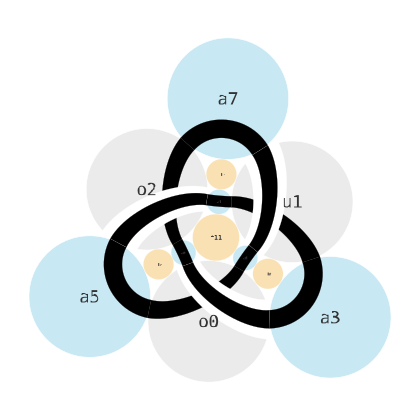

In [16]:
signed = SIGNED_GAUSS_EXAMPLES["3_1"]  # positive means over
enhanced = signed_gauss_to_enhanced(signed, over_is_positive=True)
trefoil = diagram_from_gauss(signed, over_is_positive=True)

print("signed Gauss:  ", signed)
print("derived enhanced: ", enhanced)
print()
print("meta-graph nodes:")
print(describe_nodes(trefoil["nodes"]))

show_svg(render_svg(trefoil, show_circles=True, labels=True))


## Coordinates from circle packing

Each original crossing, original arc, and discovered face becomes a circle. After choosing an
outer face, its boundary circles are pinned and the Collins-Stephenson iteration solves the
remaining radii. The crossing circle centers are the crossing coordinates.


outer face: 27
id  kind          x          y      radius
 0  over    -3.25016   -2.21391   1.00000
 1  under   -3.93159    0.08707   1.00000
 2  over    -1.12722    1.32899   1.00000
 3  under    0.00000    0.00000   0.30332
 4  over     0.52279    0.15482   0.15847
 5  under    1.74285    0.51614   1.00000
 6  over    -0.22176   -1.72849   1.00000
 7  under   -2.00485   -0.59373   0.57191


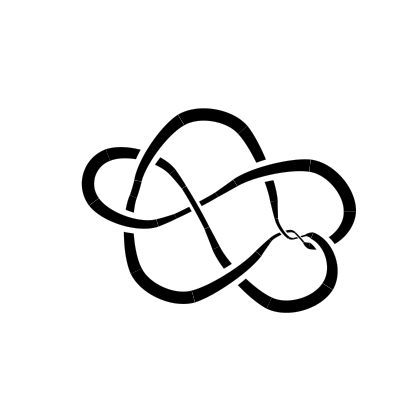

In [17]:
diagram_8_11 = diagram_from_gauss(SIGNED_GAUSS_EXAMPLES["8_11"], over_is_positive=True)
print("outer face:", diagram_8_11["outer_face"])
print(coordinate_table(packed_coordinates(diagram_8_11["nodes"], diagram_8_11["layout"], crossing_only=True)))

show_svg(render_svg(diagram_8_11))


## Choosing the outer face

The embedding is fixed, but the visual projection changes when a different face is sent to
infinity. Rideout's heuristic is to choose a face with many boundary edges; this usually
avoids very small circles near the outside.


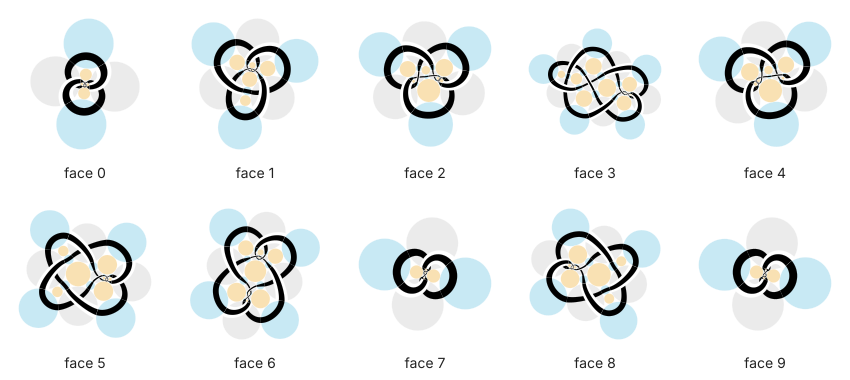

In [18]:
nodes_8_11 = diagram_from_gauss(SIGNED_GAUSS_EXAMPLES["8_11"], over_is_positive=True)["nodes"]
items = [
    {
        "label": f"face {i}",
        "diagram": diagram_from_nodes(nodes_8_11, outer_face=i),
        "show_circles": True,
    }
    for i in range(len(face_ids(nodes_8_11)))
]
show_svg(gallery_svg(items, columns=5, cell_width=170, cell_height=190))


## Filled variable-width outlines

The renderer below follows the production blog renderer's layering model: draw the under
strand, draw a wider white filled outline, then redraw the over strand. This notebook keeps
the implementation dependency-free by sampling each cubic Bezier into a filled offset outline.
The production source used a Bezier offset library for print-quality outlines.


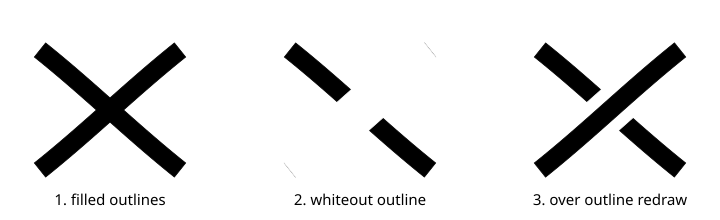

In [19]:
show_svg(crossing_layers_demo())


## More examples

The same coordinate and renderer functions handle all examples below; there are no per-knot
manual coordinates.


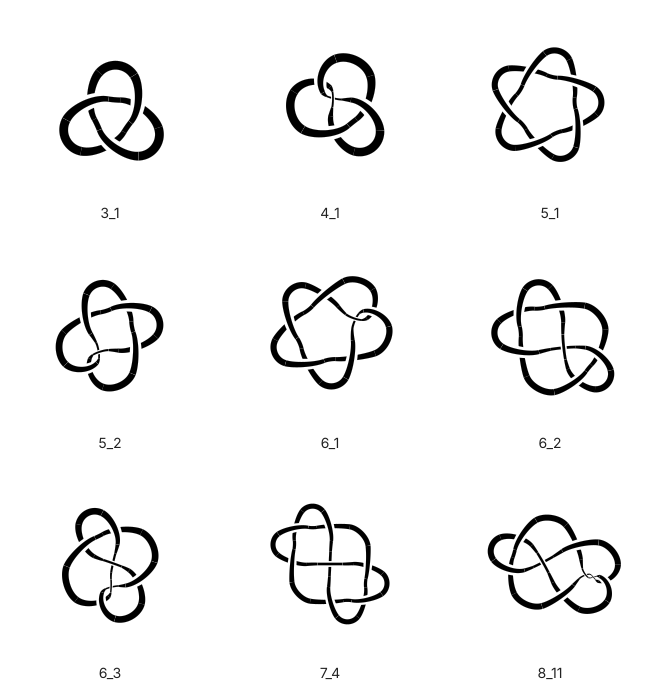

In [20]:
example_names = ["3_1", "4_1", "5_1", "5_2", "6_1", "6_2", "6_3", "7_4", "8_11"]
items = [
    {"label": name, "diagram": diagram_from_gauss(SIGNED_GAUSS_EXAMPLES[name], over_is_positive=True)}
    for name in example_names
]
show_svg(gallery_svg(items, columns=3, cell_width=220, cell_height=230))


## Guarantees and limitations

Circle packing preserves a planar combinatorial embedding; it does not prove that an arbitrary
signed Gauss code is crossing-minimal for its knot type. So "minimal intersection" means
no unintended intersections are introduced by the layout. Crossing minimality must come from
the input table or from a separate simplification/certification step.

This notebook handles one-component classical knots. Links require component-aware traversal
in the signed-Gauss helpers.


# Appendix: Optional PD adapter

The main pipeline above starts from signed Gauss codes. If you happen to have a standard
one-component PD code, this adapter traces the component and converts it to the same signed
Gauss convention before entering the main pipeline.


In [21]:
def pd_to_signed_gauss(pd, over_is_positive=True):
    """Trace a one-component standard PD code and return a signed Gauss word."""
    incoming = {}
    outgoing = {}
    for crossing, (a, b, c, d) in enumerate(pd, start=1):
        incoming[a] = (crossing, "u")
        outgoing[a] = c
        incoming[d] = (crossing, "o")
        outgoing[d] = b

    labels = sorted(incoming)
    if set(outgoing) != set(labels):
        raise ValueError("PD labels should form one closed component")

    relabel = {}
    result = []
    current = labels[0]
    seen_edges = set()
    for _ in range(len(labels)):
        if current in seen_edges:
            raise ValueError("PD traversal closed before all edges were seen")
        seen_edges.add(current)
        crossing, over_under = incoming[current]
        if crossing not in relabel:
            relabel[crossing] = len(relabel) + 1
        sign = 1 if over_under == "o" else -1
        if not over_is_positive:
            sign *= -1
        result.append(sign * relabel[crossing])
        current = outgoing[current]

    if current != labels[0] or seen_edges != set(labels):
        raise ValueError("this helper expects a one-component PD code")
    return result


def nodes_from_pd(pd):
    """Convert standard PD tuples X[a,b,c,d] into the packing meta-graph."""
    n = len(pd)
    labels = sorted({label for crossing in pd for label in crossing})
    arc_id = {label: n + index for index, label in enumerate(labels)}
    rotations = {}
    node_types = {}
    arc_occurrences = {label: [] for label in labels}

    for crossing, (a, b, c, d) in enumerate(pd):
        # PD is counterclockwise from incoming lower edge.
        # The packing code uses clockwise order, with 0 and 2 on the under strand.
        clockwise_labels = [a, d, c, b]
        rotations[crossing] = [arc_id[label] for label in clockwise_labels]
        node_types[crossing] = "under"
        for label in clockwise_labels:
            arc_occurrences[label].append(crossing)

    for label, endpoints in arc_occurrences.items():
        if len(endpoints) != 2:
            raise ValueError(f"PD edge label {label} appears {len(endpoints)} times")
        rotations[arc_id[label]] = endpoints

    return build_meta_graph(rotations, node_types)


def diagram_from_pd(pd_code, outer_face=None):
    """Optional adapter: PD code in, packed diagram data out."""
    return diagram_from_nodes(nodes_from_pd(pd_code), outer_face)


def coordinates_from_pd(pd_code, outer_face=None, crossing_only=True):
    diagram = diagram_from_pd(pd_code, outer_face)
    return packed_coordinates(diagram["nodes"], diagram["layout"], crossing_only)


The appendix example is deliberately separate from the main pipeline: PD is only a convenience
input adapter here.


signed Gauss recovered from PD: [1, -2, 3, -1, 2, -3]


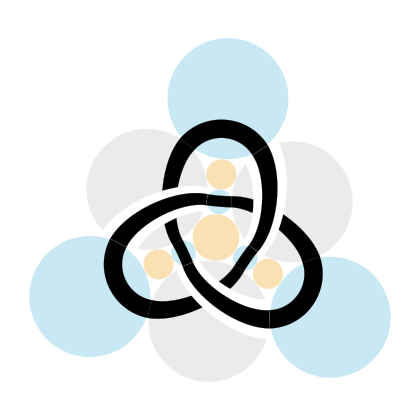

In [22]:
trefoil_pd = [
    (4, 2, 5, 1),
    (6, 4, 1, 3),
    (2, 6, 3, 5),
]
recovered_signed = pd_to_signed_gauss(trefoil_pd, over_is_positive=True)
print("signed Gauss recovered from PD:", recovered_signed)
show_svg(render_svg(diagram_from_gauss(recovered_signed, over_is_positive=True), show_circles=True))
